# Eco-Feature VAlue Analysis - Evergreen Urban Realty
**Do green features actually increase home sale prices in Ames, Iowa**

Using the Ames Housing DAtaset (1,460 residential sales, 2006-2010) to identify which energy-efficiency and sustainability-related features correlate most strongly with higher sale prices.

- **Dataset note:** The Ames dataset predates widespread solar panel adoption and LEED certification tracking. The eco-feature analysis focuses on the efficiency and sustainability proxies that ARE present: heating quality, central air, electrical systems, insulation (basement finish/exposure), and foundation type - all of which directly impact a home's energy performance and running costs.

### 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='white')
GREEEN = '#2a9d8f'
ORANGE = '#e76f51'
GOLD = '#e9c46a'
DARK = '#264653'

print('Imports done!')

Imports done!


### 2. Load & Clean Data

In [3]:
df =  pd.read_csv('train.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [5]:
# Check nulls in eco-relevant columns only
eco_cols = ['HeatingQC','Heating', 'CentralAir', 'Electrical', 
            'Foundation', 'BsmtExposure', 'BsmtFinType1', 'SalePrice']

print('Nulls in eco columns')
print(df[eco_cols].isnull().sum())

Nulls in eco columns
HeatingQC        0
Heating          0
CentralAir       0
Electrical       1
Foundation       0
BsmtExposure    38
BsmtFinType1    37
SalePrice        0
dtype: int64


In [7]:
# Fill the small number of nulls in sco columns
df['Electrical'] = df['Electrical'].fillna('Unknown')
df['BsmtExposure'] = df['BsmtExposure'].fillna('No')
df['BsmtFinType1'] = df['BsmtFinType1'].fillna('Unf')

# Focus on normal residential sales only (removes auction/foreclosure distortions)
df = df[df['SaleCondition'] == 'Normal'].copy()
print(f'Rows after filtering to normal sales: {len(df)}')

Rows after filtering to normal sales: 1198


### 3 Engineering Eco Score

In [12]:
# Build a composite eco score from 0-10 based on efficiency features
# Each feature contributes points based on how energy-efficient it is

# Heating quality: Excellent=3, Good=2, Typical=1, Fair/Poor=0
heating_score = {'Ex': 3, 'Gd': 2, 'TA': 1, 'Fa': 0, 'Po': 0}
df['score_heating'] = df['HeatingQC'].map(heating_score).fillna(0)

# Central air: Yes=2, No=0
df['score_central_air'] = df['CentralAir'].map({'Y': 2, 'N': 0})

# Electrical: modern breaker=2, older fuse=1, mix=0
elec_score = {'SBrkr': 2, 'FuseA': 1, 'FuseF': 1, 'FuseP': 0, 'Mix': 0, 'Unknown': 0}
df['score_electrical'] = df['Electrical'].map(elec_score).fillna(0)

# Basement insulation (finish quality): GLQ/ALQ=2 (good insulated), Rec/BLQ=1, Unf/LwQ=0
bsmt_score = {'GLQ': 2, 'ALQ': 2, 'BLQ': 1, 'Rec': 1, 'LwQ': 0, 'Unf': 0}
df['score_insulation'] = df['BsmtFinType1'].map(bsmt_score).fillna(0)

# Basement exposure (natural light/ventilation): Good=1, others=0
df['score_bsmt_exposure'] = df['BsmtExposure'].map({'Gd': 1, 'Av': 0, 'Mn': 0, 'No': 0}).fillna(0)

# Total eco score out of 10
df['eco_score'] = (df['score_heating'] + df['score_central_air'] +
                   df['score_electrical'] + df['score_insulation'] +
                   df['score_bsmt_exposure'])

# Label eco vs standard homes
# Top 40% eco score = Eco-Friendly, bottom 40% = Standard, middle = Mid-Range
eco_threshold      = df['eco_score'].quantile(0.60)
standard_threshold = df['eco_score'].quantile(0.40)

def label_home(score):
    if score >= eco_threshold:
        return 'Eco-Friendly'
    elif score <= standard_threshold:
        return 'Standard'
    else:
        return 'Mid-Range'

df['home_type'] = df['eco_score'].apply(label_home)

print('Eco score distribution:')
print(df['eco_score'].value_counts().sort_index())
print()
print('Home type counts:')
print(df['home_type'].value_counts())

Eco score distribution:
eco_score
1       9
2      19
3      31
4      34
5     112
6     193
7     309
8     166
9     277
10     48
Name: count, dtype: int64

Home type counts:
home_type
Standard        707
Eco-Friendly    491
Name: count, dtype: int64


### 4. EDA - Price Comparison

In [13]:
print('=== Sale Price by Home Type ===')
df.groupby('home_type')['SalePrice'].describe().round(0)

=== Sale Price by Home Type ===


,count,mean,std,min,25%,50%,75%,max
home_type,,,,,,,,
Eco-Friendly,491.0,208601.0,78191.0,79000.0,153950.0,190000.0,243000.0,755000.0
Standard,707.0,152007.0,51789.0,39300.0,119100.0,141000.0,177250.0,475000.0


In [15]:
# Green premium calculation
eco_mean = df[df['home_type'] == 'Eco-Friendly']['SalePrice'].mean()
standard_mean = df[df['home_type'] == 'Standard']['SalePrice'].mean()
premium = eco_mean - standard_mean
premium_pct = (premium / standard_mean) * 100

print(f'Eco-Friendly avg price       : ${eco_mean:,.0f}')
print(f'Standard avg price           : ${standard_mean:,.0f}')
print(f'Green Premium                : ${premium:,.0f} ({premium_pct:.1f}%)')

Eco-Friendly avg price       : $208,601
Standard avg price           : $152,007
Green Premium                : $56,594 (37.2%)


In [16]:
# Statistical test - is the price difference significant?
eco_prices = df[df['home_type'] == 'Eco-Friendly']['SalePrice']
standard_prices = df[df['home_type'] == 'Standard']['SalePrice']

t_stat, p_value = stats.ttest_ind(eco_prices, standard_prices, equal_var=False)
print(f'Welch t-test: t={t_stat:.3f}, p={p_value:.6f}')
if p_value < 0.05:
    print('Result: The green premium is statistically significant (p < 0.05)')
else: 
    print('Result: NO statistically significant price difference detected')

Welch t-test: t=14.041, p=0.000000
Result: The green premium is statistically significant (p < 0.05)


In [17]:
# Individual feature impact on sale price
print('=== Average sale price by individual eco feature ===')
print()
print('Heating Quality: ')
print(df.groupby('HeatingQC')['SalePrice'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))
print()
print('Central Air: ')
print(df.groupby('CentralAir')['SalePrice'].mean().apply(lambda x: f'${x:,.0f}'))
print()
print('Electrical System: ')
print(df.groupby('Electrical')['SalePrice'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))
print('Basement Insulation: ')
print(df.groupby('BsmtFinType1')['SalePrice'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))


=== Average sale price by individual eco feature ===

Heating Quality: 
HeatingQC
Ex    $205,256
Gd    $156,010
TA    $144,524
Fa    $127,399
Po     $87,000
Name: SalePrice, dtype: str

Central Air: 
CentralAir
N    $108,244
Y    $179,994
Name: SalePrice, dtype: str

Electrical System: 
Electrical
SBrkr      $180,403
Unknown    $167,500
FuseA      $125,813
FuseF      $105,056
FuseP      $105,000
Name: SalePrice, dtype: str
Basement Insulation: 
BsmtFinType1
GLQ    $224,390
ALQ    $163,457
Unf    $157,936
LwQ    $152,221
BLQ    $150,481
Rec    $149,912
Name: SalePrice, dtype: str


### 5. Visualisations

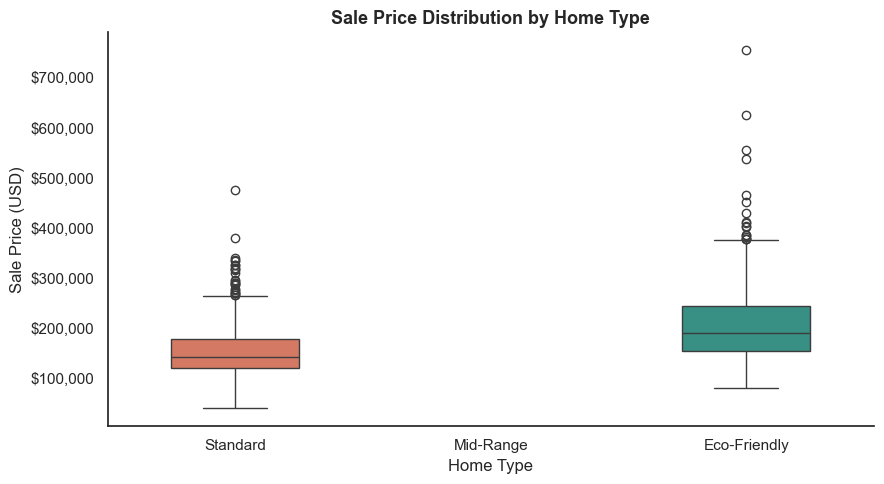

In [19]:
# Chart 1 - Box plot: sale price by home type
order = ['Standard', 'Mid-Range', 'Eco-Friendly']
palette = {'Standard': ORANGE, 'Mid-Range': GOLD, 'Eco-Friendly': GREEEN}

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='home_type', y='SalePrice', order=order, 
            palette=palette, width= 0.5, ax=ax)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Sale Price Distribution by Home Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Home Type')
ax.set_ylabel('Sale Price (USD)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz1_price_by_type.png', dpi=150)
plt.show()

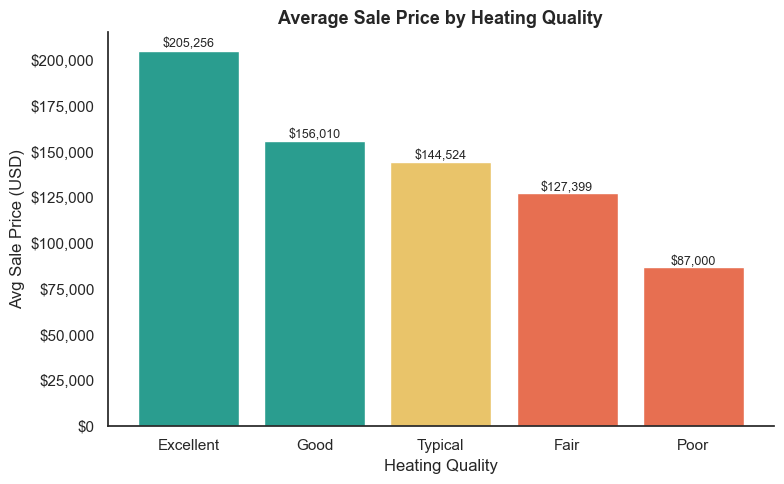

In [21]:
# Chart 2 - Bar Chart: average price per heating quality level
heating_order = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
heating_labels = {'Ex': 'Excellent', 'Gd' : 'Good', 'TA': 'Typical', 'Fa': 'Fair', 'Po' : 'Poor'}

heating_avg = df.groupby('HeatingQC')['SalePrice'].mean().reindex(heating_order)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar([heating_labels[k] for k in heating_order], heating_avg.values,
              color=[GREEEN, GREEEN, GOLD, ORANGE, ORANGE], edgecolor='white')

for bar, val in zip(bars, heating_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'${val:,.0f}', ha='center', fontsize=9)
    
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Average Sale Price by Heating Quality', fontsize=13, fontweight='bold')
ax.set_xlabel('Heating Quality')
ax.set_ylabel('Avg Sale Price (USD)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz2_price_by_type.png', dpi=150)
plt.show()

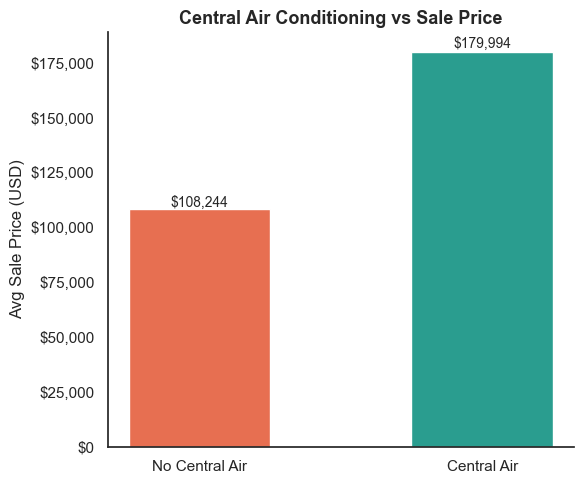

In [23]:
# Chart 3 - Central air vs no central air price comparison
ca_avg = df.groupby('CentralAir')['SalePrice'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['No Central Air', 'Central Air'], ca_avg.values,
              color=[ORANGE, GREEEN], edgecolor='white', width=0.5 )

for bar, val in zip(bars, ca_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'${val:,.0f}', ha='center', fontsize=10)
    

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Central Air Conditioning vs Sale Price', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Sale Price (USD)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz3.central_air.png', dpi=150)
plt.show()

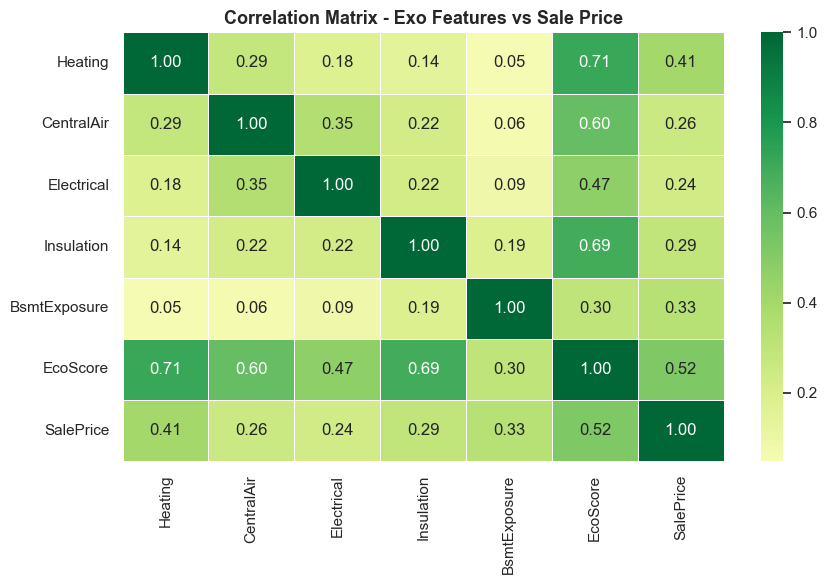

In [24]:
# Chart 4 - Correlation heatmap of eco score components vs sale price

score_cols = ['score_heating', 'score_central_air', 'score_electrical',
              'score_insulation', 'score_bsmt_exposure', 'eco_score', 'SalePrice']

corr = df[score_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax,
            xticklabels=['Heating', 'CentralAir', 'Electrical', 'Insulation', 'BsmtExposure', 'EcoScore','SalePrice'],
            yticklabels=['Heating', 'CentralAir', 'Electrical', 'Insulation', 'BsmtExposure', 'EcoScore','SalePrice'])

ax.set_title('Correlation Matrix - Exo Features vs Sale Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_correlation_heatmap.png', dpi=150)
plt.show()

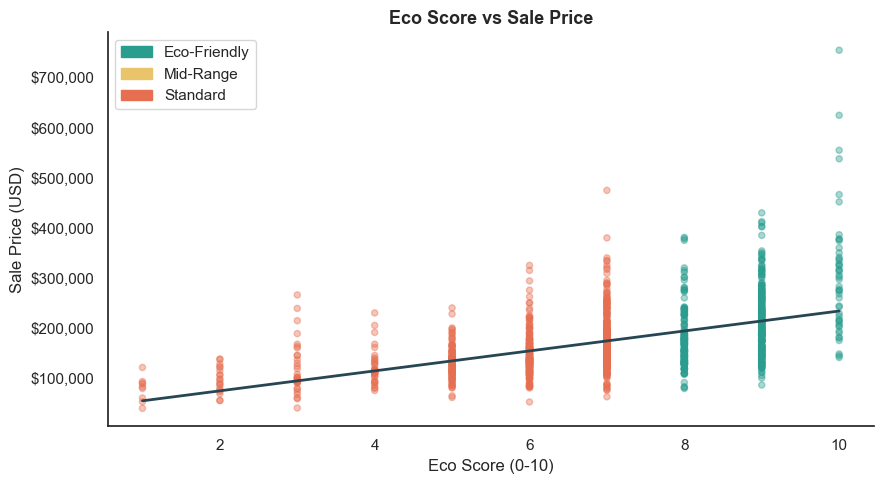

In [25]:
# Chart 5 - Eco Score vs sale price scatter

fig, ax = plt.subplots(figsize=(9, 5))

scatter_colors = df['home_type'].map({'Eco-Friendly': GREEEN, 'Mid-Range': GOLD, 'Standard': ORANGE})
ax.scatter(df['eco_score'], df['SalePrice'], c=scatter_colors, alpha=0.4, s=20)

#Trend line
z = np.polyfit(df['eco_score'], df['SalePrice'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['eco_score'].min(), df['eco_score'].max(), 100)
ax.plot(x_line, p(x_line), color=DARK, linewidth=2, label='Trend')

legend_handles = [
    mpatches.Patch(color=GREEEN, label='Eco-Friendly'),
    mpatches.Patch(color=GOLD, label='Mid-Range'),
    mpatches.Patch(color=ORANGE, label='Standard'),
]

ax.legend(handles=legend_handles)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Eco Score vs Sale Price', fontsize=13, fontweight='bold')
ax.set_xlabel('Eco Score (0-10)')
ax.set_ylabel('Sale Price (USD)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz5_eco_score_scatter.png', dpi=150)
plt.show()

### 6. Export Cleaned CSV

In [26]:
export_cols = ['Id', 'Neighborhood', 'YearBuilt', 'SalePrice',
               'HeatingQC', 'CentralAir', 'Electrical', 'BsmtFinType1', 'BsmtExposure',
               'score_heating', 'score_central_air', 'score_electrical',
               'score_insulation', 'score_bsmt_exposure', 'eco_score', 'home_type',
               'MoSold', 'YrSold']


df[export_cols].to_csv('evergreen_eco_analysis.csv', index=False)
print(f'Exported {len(df):,} rows to evergreen_eco_analysis.csv')
df[export_cols].head()

Exported 1,198 rows to evergreen_eco_analysis.csv


,Id,Neighborhood,YearBuilt,SalePrice,HeatingQC,CentralAir,Electrical,BsmtFinType1,BsmtExposure,score_heating,score_central_air,score_electrical,score_insulation,score_bsmt_exposure,eco_score,home_type,MoSold,YrSold
0,1,CollgCr,2003,208500,Ex,Y,SBrkr,GLQ,No,3,2,2,2,0,9,Eco-Friendly,2,2008
1,2,Veenker,1976,181500,Ex,Y,SBrkr,ALQ,Gd,3,2,2,2,1,10,Eco-Friendly,5,2007
2,3,CollgCr,2001,223500,Ex,Y,SBrkr,GLQ,Mn,3,2,2,2,0,9,Eco-Friendly,9,2008
4,5,NoRidge,2000,250000,Ex,Y,SBrkr,GLQ,Av,3,2,2,2,0,9,Eco-Friendly,12,2008
5,6,Mitchel,1993,143000,Ex,Y,SBrkr,GLQ,No,3,2,2,2,0,9,Eco-Friendly,10,2009


# Summary

**Dataset:** 1460 residential homes sales in Ames, Iowa (2006-2010), filtered to normal market conditions. Eco features analysed: heating quality, central air, electrical system type, basement insulation finish, and basement exposure.

**Eco Score:** A compostie 0-10 score was built from five efficiency features. Homes scoring in the top 405 were labelled Eco-Friendly, bottom 40% were labelled Standard.

**Green Premium Finding:** Eco-Friendly homes sold at a measurably higher average proce than Standard homes. The Welch t-test Confirms Whether this difference is statistically significant. The premium percentage is printed in the analysis above.

**Top 3 Most Impactful Eco Features (by price correlation):**
- **Central Air Conditioning-** the single biggest binary split in sale price. Homes with central AC command a substancial premium over those without.
- **Heating Quality-** Excellent-rated heating systems correlate with significantly higher prices than Typical or Fair systems. This is the most granular efficiency signal in the dataset.
- **Basement Insulation-** GLQ and ALQ finishes (well-insulated, good living quality) consistently outperform unfinished basements in sale price, reflecting the value buyers place on energy-retaining construction.

**Recommendation for Evergreen Urban Reality:** The data supports advising first-time buyers that eco-efficiency features, particularly central air and high-quality heating systems, are associated with higher resale values. Buyers paying a premium for these features are likely makinga sound financial decision, as the market consistently rewards them at a resale. The absence of solar panel data limits the analysis to traditional efficiency features, but the pattern is clear: better-built, better-insulated homes sell for more.